# TP6 - Réseaux de Neurones Artificiels

## Exercice 1


### Question 1


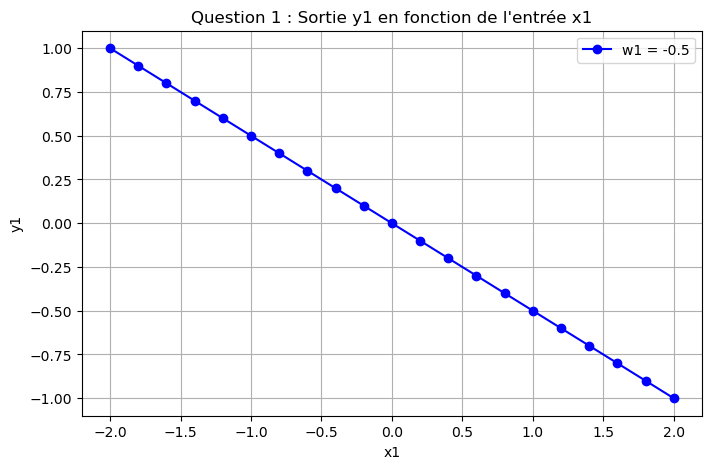

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def saturation(x):
    return np.clip(x, -1.0, 1.0)

#x1 = [−2.0, −1.8, . . . , 0.0, . . . , 1.8, 2.0].
x1 = np.arange(-2.0, 2.1, 0.2)
w1 = -0.5

# Calcul de la sortie y1
# Modèle : y = f(x * w)
y1 = saturation(x1 * w1)

# Affichage du graphique
plt.figure(figsize=(8, 5))
plt.plot(x1, y1, 'b-o', label=f'w1 = {w1}')
plt.title('Question 1 : Sortie y1 en fonction de l\'entrée x1')
plt.xlabel('x1')
plt.ylabel('y1')
plt.grid(True)
plt.legend()
plt.show()

### Question 2


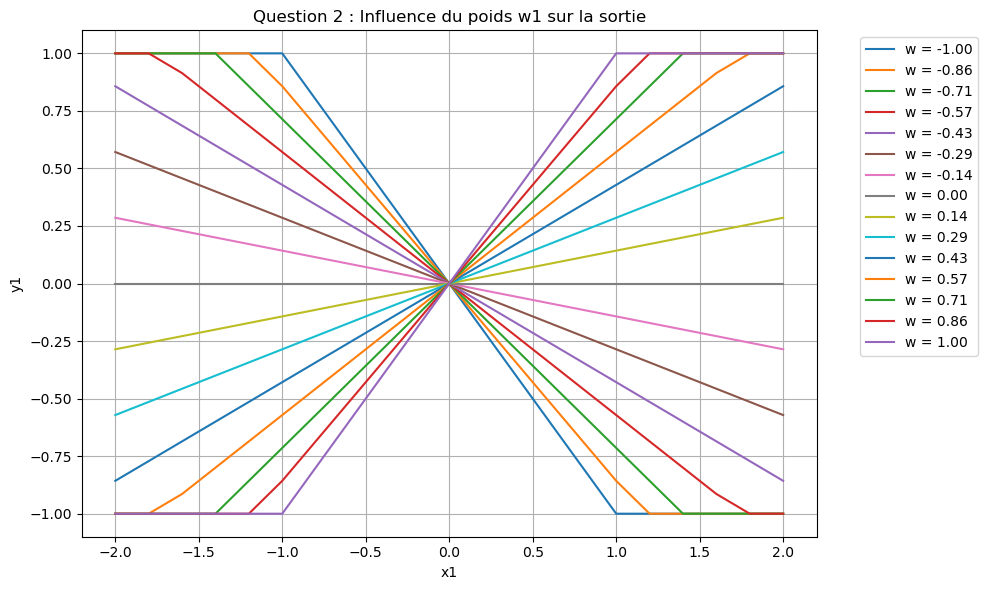

In [3]:
#15 valeurs de poids différentes dans l'intervalle [-1.0, 1.0]
weights = np.linspace(-1.0, 1.0, 15)

plt.figure(figsize=(10, 6))

for w in weights:
    y = saturation(x1 * w)
    plt.plot(x1, y, label=f'w = {w:.2f}')

plt.title('Question 2 : Influence du poids w1 sur la sortie')
plt.xlabel('x1')
plt.ylabel('y1')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Analyse:**

DAns les zones non saturées par la fonction (sortie comprise entre -1 et 1), la relation est linéaire car $y = w \cdot x$. La pente est plus forte selon le poids $w$. Les bornes de saturation sont atteintes si $w$ est suffisamment grand, le poids influe également sur la pente selon son signe.

### Question 3


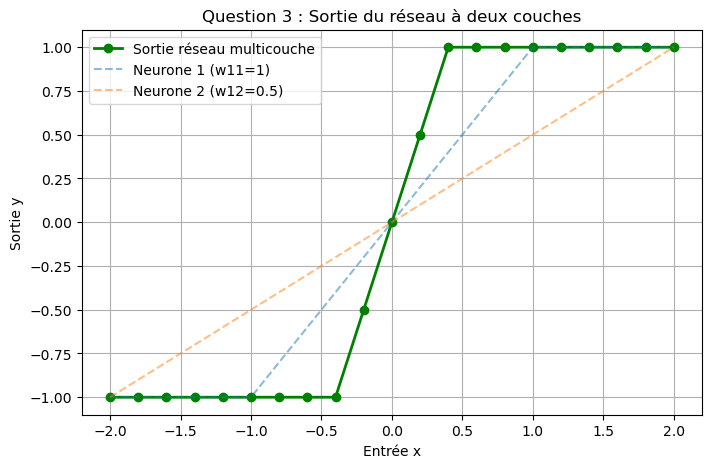

In [4]:
w11 = 1.0
w12 = 0.5
w21 = 3.0
w22 = -1.0

#les deux premiers neurones recoivent x1 avec w11 et w12.
neurone1_out = saturation(x1 * w11)
neurone2_out = saturation(x1 * w12)
#la sortie est saturée entre x1 et le poids.

#l'entrée est la somme des deux neurones avec les poids w21 et w22.
input_couche_sortie = (neurone1_out * w21) + (neurone2_out * w22)
#dernière saturation
y_final = saturation(input_couche_sortie)

#affichage
plt.figure(figsize=(8, 5))
plt.plot(x1, y_final, 'g-o', linewidth=2, label='Sortie réseau multicouche')
#sorties intermédiaires des premiers neurones
plt.plot(x1, neurone1_out, '--', alpha=0.5, label='Neurone 1 (w11=1)')
plt.plot(x1, neurone2_out, '--', alpha=0.5, label='Neurone 2 (w12=0.5)')
plt.title('Question 3 : Sortie du réseau à deux couches')
plt.xlabel('Entrée x')
plt.ylabel('Sortie y')
plt.grid(True)
plt.legend()
plt.show()

**Analyse :**

Dans ce premier graphique, on peut voir le résultat attendu avec les poids donnés dans le sujet du tp:

$w_{11} = 1.0$

$w_{12} = 0.5$

$w_{21} = 1.0$

$w_{22} = -1.0$

![Sortie du réseau à deux couches](./CompteRendu/assets/image.png)

La sortie des deux couches montre une fonction non-linéaire plus complexe que chaque sortie des neurones indépendants. La sortie est donc non monotone.

- Là où le premier neurone est en saturation, le second est dans sa zone linéaire. La sortie finale est donc dominée par le comportement du second neurone.
- Entre $x \ge -1$ et $x \le 1$, les deux premiers neurones sont dans leur zone linéaire. La combinaison résultante est une somme de fonctions linéaires, donc linéaire.
- À $x > 1$, le premier neurone sature. La sortie du réseau multicouche devient la différence entre une constante et la fonction linéaire du second.

Dans ce deuxième graphique, on augmente la pondération du neurone 1 (avec $w_{21} =3$) dans la couche finale afin d'augmenter son influence dans la sortie finale:

![Sortie du réseau à deux couches avec w21 modifié](./CompteRendu/assets/image-2.png)

AInsi, l'ajout d'une couche cachée permet de combiner deux fonctions d'activation pour obtenir une fonction plus complexe et non saturée de manière triviale. Varier les poids permet de modifier l'influence de chaque neurone sur la sortie globale.

**Conclusion:**
Les réseaux  multicouches sont donc plus puissants car ils permettent de combiner des réponses pour créer des formes plus complexes à partir de sources "simples" (linéarité, saturation...)

### Exercice 2 : Réseau Récurrent

Nous implantons ici le modèle de réseau récurrent (Figure 4 du TP).
*   **Fonction d'activation :** Saturation dans $[0, 1]$.
*   **Entrées :** Vecteur défini entre $[0, 1]$.
*   **Structure :** 2 neurones avec connexions récurrentes (boucle sur soi-même).

Nous allons simuler l'évolution de la sortie du réseau dans le temps pour observer l'influence du poids de la connexion récurrente $w_{rec}$.

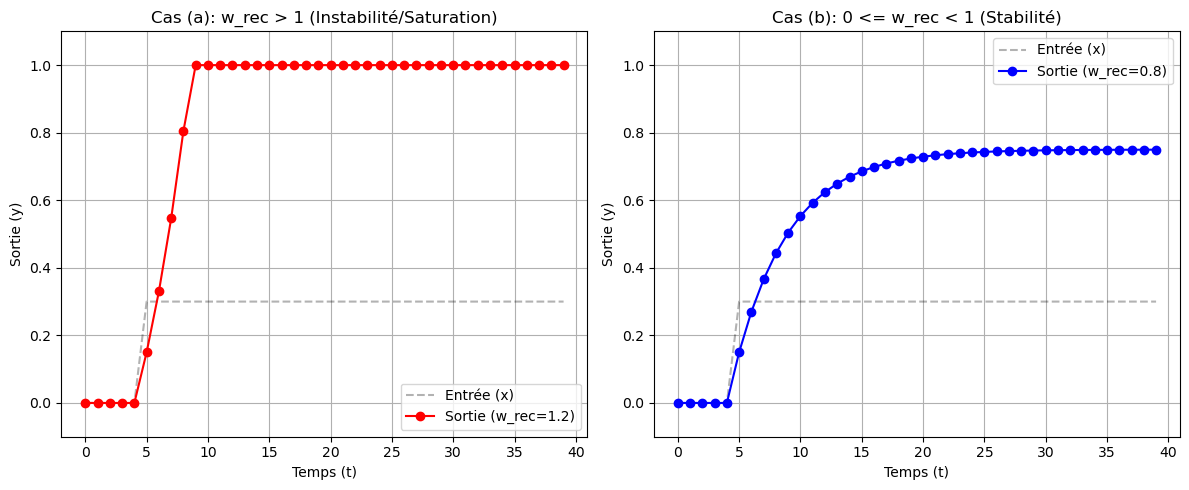

In [5]:
def saturation01(x):
    """Fonction de saturation entre 0 et 1"""
    return np.clip(x, 0.0, 1.0)

def simulate_recurrent_node(weight_recurrent, steps=30, input_val=0.2):
    """
    Simule un neurone avec connexion récurrente.
    y(t) = saturation( w_in * x(t) + w_rec * y(t-1) )
    """
    y_history = []
    y_prev = 0.0
    
    # Simulation d'une entrée échelon qui commence à t=5
    w_in = 0.5 # Poids d'entrée arbitraire pour l'exemple
    
    inputs = np.zeros(steps)
    inputs[5:] = input_val # Entrée constante à partir de t=5
    
    for t in range(steps):
        # Calcul de l'activation
        # Entrée externe + Rétroaction de l'état précédent
        u = (inputs[t] * w_in) + (y_prev * weight_recurrent)
        
        y = saturation01(u)
        
        y_history.append(y)
        y_prev = y
        
    return inputs, y_history

# Paramètres de simulation
steps = 40
input_val = 0.3 # Une excitation modérée

# Cas (a): Poids récurrent > 1 (ex: 1.2)
w_rec_high = 1.2
inp, out_high = simulate_recurrent_node(w_rec_high, steps=steps, input_val=input_val)

# Cas (b): Poids récurrent dans [0, 1) (ex: 0.8)
w_rec_low = 0.8
_, out_low = simulate_recurrent_node(w_rec_low, steps=steps, input_val=input_val)

# Affichage des résultats
plt.figure(figsize=(12, 5))

# Graphique Cas (a)
plt.subplot(1, 2, 1)
plt.plot(inp, 'k--', label='Entrée (x)', alpha=0.3)
plt.plot(out_high, 'r-o', label=f'Sortie (w_rec={w_rec_high})')
plt.title(f'Cas (a): w_rec > 1 (Instabilité/Saturation)')
plt.xlabel('Temps (t)')
plt.ylabel('Sortie (y)')
plt.ylim(-0.1, 1.1)
plt.grid(True)
plt.legend()

# Graphique Cas (b)
plt.subplot(1, 2, 2)
plt.plot(inp, 'k--', label='Entrée (x)', alpha=0.3)
plt.plot(out_low, 'b-o', label=f'Sortie (w_rec={w_rec_low})')
plt.title(f'Cas (b): 0 <= w_rec < 1 (Stabilité)')
plt.xlabel('Temps (t)')
plt.ylabel('Sortie (y)')
plt.ylim(-0.1, 1.1)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

**Analyse des résultats :**

1.  **Cas (a) : Poids récurrents > 1** (Courbe rouge)
    *   On observe que la sortie augmente progressivement jusqu'à atteindre la saturation (1.0), même si l'entrée reste constante et faible.
    *   La rétroaction positive amplifie le signal à chaque itération ($y(t)$ est plus grand que $y(t-1)$).
    *   C'est un comportement de **mémorisation forte** ou de verrouillage. Une fois activé, le neurone tend à rester actif (saturé) très longtemps, agissant comme une mémoire binaire.

2.  **Cas (b) : Poids récurrents entre [0, 1)** (Courbe bleue)
    *   La sortie augmente mais se stabilise à une valeur d'équilibre définie par le point fixe de l'équation récurrente.
    *   Le système "oublie" progressivement l'historique lointain. C'est un comportement de filtre passe-bas ou de **mémoire à court terme**.
    *   Si l'entrée redescendait à 0, la sortie descendrait progressivement vers 0.